In [29]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [30]:
#creo funcion img full
def IQM_FF(img_gris):
  m, n = img_gris.shape
  f = np.fft.fft2(img_gris)
  fc = np.fft.fftshift(f)
  af = np.abs(fc)
  max_val = np.max(af)
  thres = max_val / 1000
  th = np.count_nonzero(af > thres)
  fm = th/(m * n)
  return fm


#Creo funcion img roi
def IQM_R(img_gris):
  m, n = img_gris.shape
  #defino el tamaño del ROI
  porcentaje = 0.4
  ancho = int(n * porcentaje)
  alto = int(m * porcentaje)
  #ubico las coordenadas iniciales de mi nueva región
  x = (n // 2) - (ancho // 2)
  y = (m // 2) - (alto // 2)
  #slicing de la matriz para obtener mi nueva región
  roi = img_gris[y : y + alto,
                 x : x + ancho]
  #ahora se aplica el algoritmo
  m_roi, n_roi = roi.shape
  f = np.fft.fft2(roi)
  fc = np.fft.fftshift(f)
  af = np.abs(fc)
  max_val = np.max(af)
  thres = max_val / 1000
  th = np.count_nonzero(af > thres)
  fm_roi = th/(m_roi * n_roi)
  return fm_roi

In [31]:
#Creo listas para guardar los valores de calidad
IQM_fullFrame = []
IQM_ROI= []

In [32]:
# Abre el video
video_path = './focus_video.mov'
captura_video = cv2.VideoCapture(video_path)

if not captura_video.isOpened():
    print("Error al abrir el archivo de video")
else:
    print("Procesando video..")
    while captura_video.isOpened():
        ret, frame = captura_video.read()  #ret es un boolean que es True si logró leer el frame correctamente   /  frame:   |matriz de píxeles de la imagen actual
        if not ret:
            break #salgo del bucle cuando me quedo sin frames

        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        #aca se aplica el algoritmo para analizar la calidad del frame
        f = IQM_FF(frame_gris)
        r = IQM_R(frame_gris)
        #el valor que devuelva agregarlo a la lista para graficar
        IQM_fullFrame.append(f)
        IQM_ROI.append(r)

# Libera el objeto de captura de video
captura_video.release()

print("Procesamiento finalizado")

Procesando video..
Procesamiento finalizado


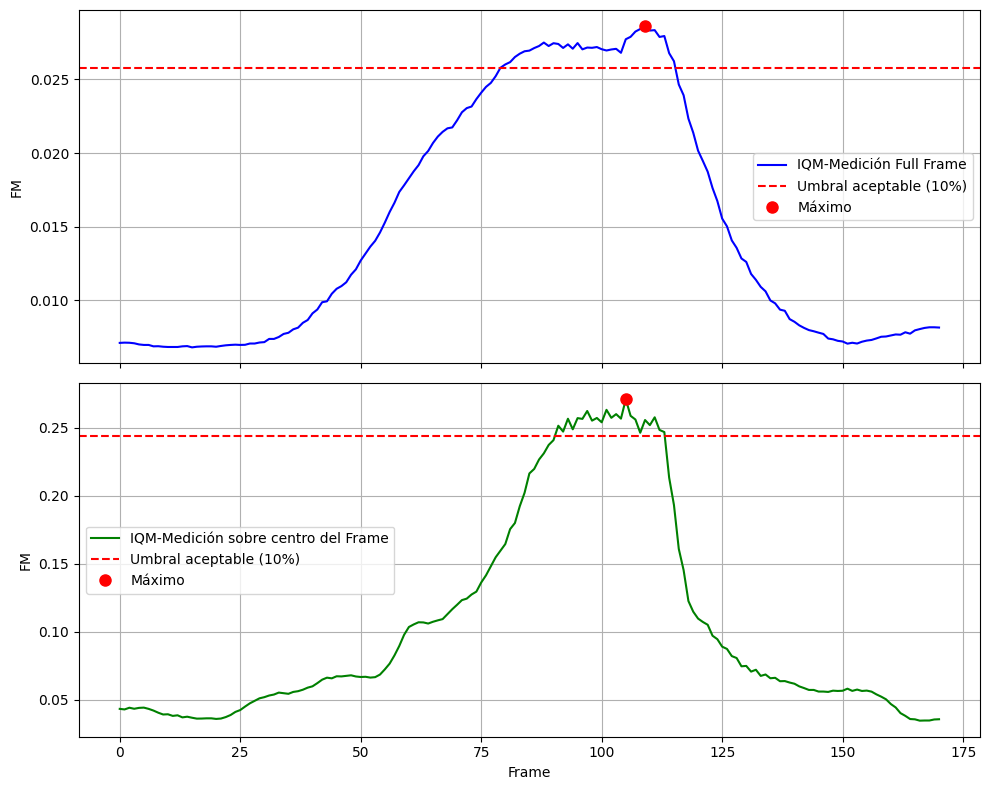

In [33]:
# Gráficos
fig, (ax1,ax2) = plt.subplots(2,1, figsize=(10,8), sharex=True)
#Full Frame
ax1.plot(IQM_fullFrame, color='blue', label='IQM-Medición Full Frame')
max_ff = max(IQM_fullFrame)
idx_max_ff = np.argmax(IQM_fullFrame)
umbral_ff = max_ff * 0.9 # voy a tomar como válidos solo los frames que tengan hasta un valor del 10% por debajo del máximo FM
ax1.axhline(y=umbral_ff, color='red', linestyle='--', label='Umbral aceptable (10%)')
ax1.plot(idx_max_ff, max_ff, 'ro', markersize=8, label='Máximo')

ax1.set_ylabel('FM')
ax1.legend()
ax1.grid(True)

#ROI
ax2.plot(IQM_ROI, color='green', label='IQM-Medición sobre centro del Frame')
max_roi = max(IQM_ROI)
idx_max_roi = np.argmax(IQM_ROI)
umbral_roi = max_roi * 0.9
ax2.axhline(y=umbral_roi, color='red', linestyle='--', label='Umbral aceptable (10%)')
ax2.plot(idx_max_roi, max_roi, 'ro', markersize=8, label='Máximo')

ax2.set_ylabel('FM')
ax2.set_xlabel('Frame')  #eje x global. Comparten el mismo
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#Tomo los frames que superan el umbral de aceptación
region_ff = [i + 1 for i, value in enumerate(IQM_fullFrame) if value >= umbral_ff]
region_roi = [i + 1 for i, value in enumerate(IQM_ROI) if value >= umbral_roi]

In [34]:
#imprimo máximos y regiones de máximo enfoque
print("Resultados")
print(f"Mejor frame (Full FRAME): {np.argmax(IQM_fullFrame) + 1} con valor {max_ff:.4f}")
print(f"Región de máximo enfoque(Full FRAME): Frames {region_ff}")
print(f"Mejor frame (ROI): {np.argmax(IQM_ROI) + 1} con valor {max_roi:.4f}")
print(f"Región de máximo enfoque(ROI): Frames {region_roi}")


Resultados
Mejor frame (Full FRAME): 110 con valor 0.0286
Región de máximo enfoque(Full FRAME): Frames [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116]
Mejor frame (ROI): 106 con valor 0.2707
Región de máximo enfoque(ROI): Frames [92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114]


Hago una prueba visual de la calidad de los frames que estan en los limites de la region vs el de mayor calidad

Para el experimento sobre Full Frames:

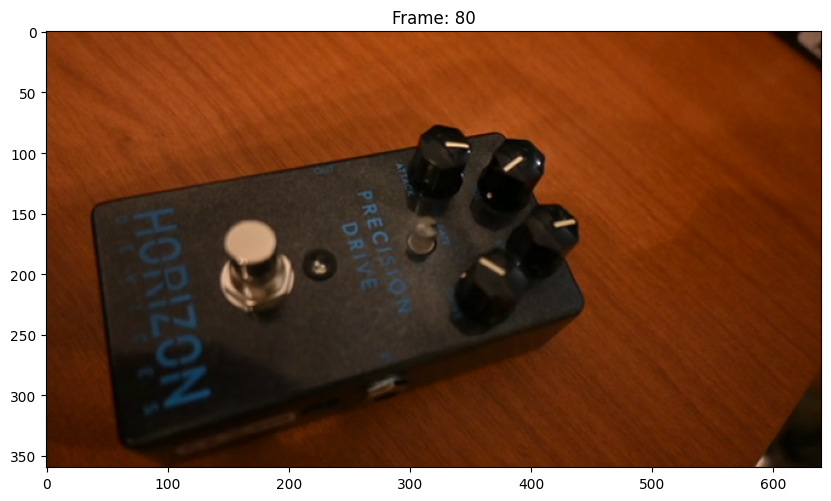

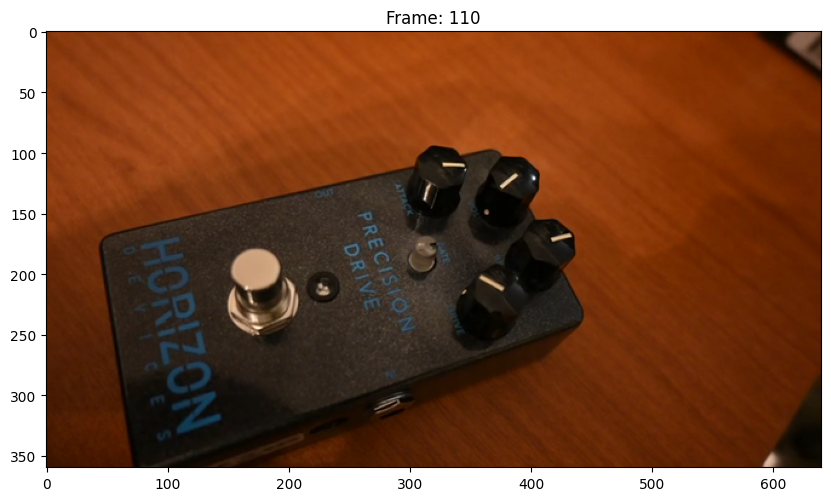

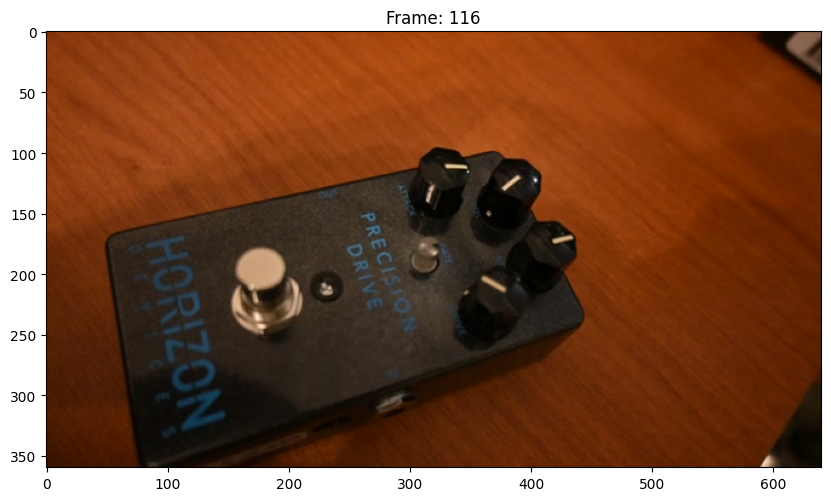

In [35]:
#Leo el video nuevamente, pero salto derecho a los frames que me interesan
frms_ff = [region_ff[0], idx_max_ff + 1, region_ff[-1]]
video_path = './focus_video.mov'
cap = cv2.VideoCapture(video_path)

for f in frms_ff:
    cap.set(cv2.CAP_PROP_POS_FRAMES, f - 1)
    ret, frame = cap.read()

    if ret:
        plt.figure(figsize=(10,6))
        frm_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frm_rgb)
        plt.title(f"Frame: {f}")
cap.release
cv2.destroyAllWindows()

Para el experimento sobre ROI:

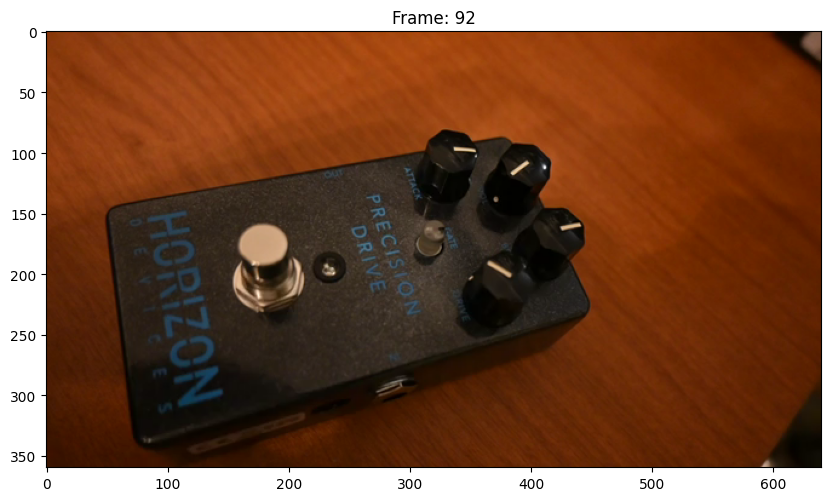

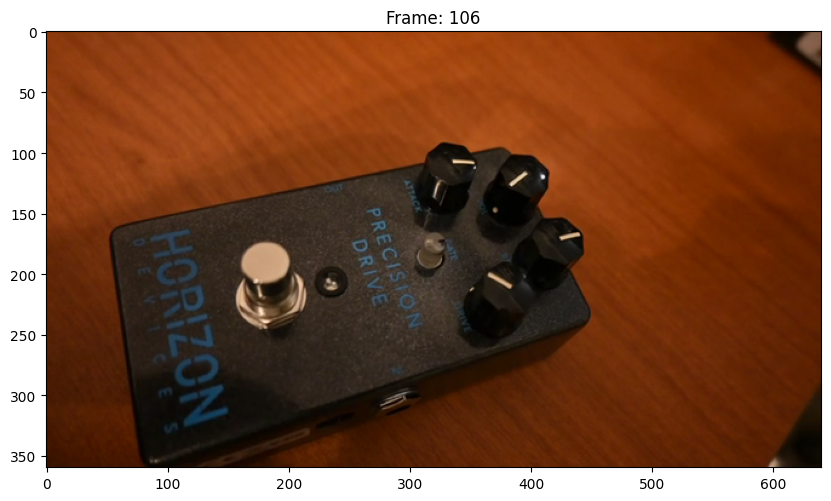

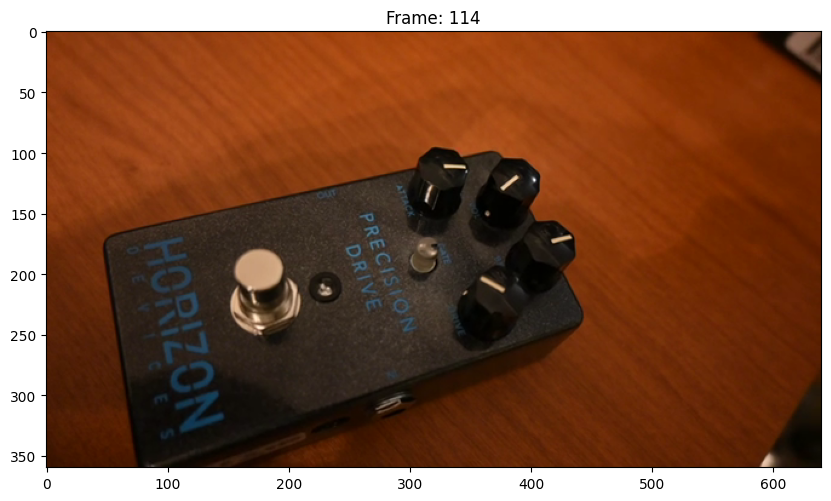

In [36]:
#Leo el video nuevamente, pero salto derecho a los frames que me interesan
frms_roi = [region_roi[0], idx_max_roi + 1, region_roi[-1]]
video_path = './focus_video.mov'
cap = cv2.VideoCapture(video_path)

for fr in frms_roi:
    cap.set(cv2.CAP_PROP_POS_FRAMES, fr - 1)
    ret, frame = cap.read()

    if ret:
        plt.figure(figsize=(10,6))
        frm_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frm_rgb)
        plt.title(f"Frame: {fr}")
cap.release
cv2.destroyAllWindows()

### Unsharp Masking

In [37]:
# Ahora definimos el algoritmo en una función para detectar frames con alto nivel de enfoque.
# Para esto, utilizamos la medida FM calculada para cada frame.
# 
# En lugar de usar un percentil definimos un umbral basado en la distribución de la señal (media y desviación estándar).
# 
# De esta forma, consideramos como "enfocados" aquellos frames cuyo valor de FM supera:
#     umbral = media + k * desviación estándar
# 
# Este criterio permite comparar distintos conjuntos de frames (por ejemplo, antes y después de un procesamiento),

def detectar_frames_enfocados(fm_values, k=1.0):
    import numpy as np
    
    fm = np.array(fm_values)
    media = np.mean(fm)
    std = np.std(fm)
    
    # Usar coeficiente de variación para hacer el criterio invariante a la escala
    cv = std / media  # coeficiente de variación
    umbral = media * (1 + k * cv)  # invariante a multiplicaciones por constante
    
    frames = [i for i, v in enumerate(fm) if v >= umbral]
    
    return frames, umbral

In [38]:
# Adaptamos función de gráfico de curva para que marque los frames enfocados
def graficar_curva_fm_con_enfoque(fm_values, frames_enfocados):
    # Convertir a array
    fm_array = np.array(fm_values)

    # Índice del máximo
    max_idx = np.argmax(fm_array)
    max_value = fm_array[max_idx]

    # Graficar
    plt.figure(figsize=(12, 6))
    plt.plot(fm_array, marker='o', label='FM')

    # Marcar el máximo
    plt.scatter(max_idx, max_value, s=100, label='Máximo enfoque')
    plt.axvline(x=max_idx, linestyle='--', label=f'Frame {max_idx}')

    # Marcar frames enfocados
    for frame in frames_enfocados:
        plt.axvline(x=frame, color='green', linestyle=':', alpha=0.5)

    plt.title('Medida de Calidad de Imagen (FM) a lo largo del tiempo')
    plt.xlabel('Número de Frame')
    plt.ylabel('FM')
    plt.grid()
    plt.legend()
    plt.show()

In [39]:
def unsharp_masking(imagen, kernel_size=(5, 5), sigma=1.0, amount=1.0):
    # Convertir a float
    imagen_float = imagen.astype(np.float32)
    
    # Desenfoque
    blurred = cv2.GaussianBlur(imagen_float, kernel_size, sigma)
    
    # Máscara
    mask = imagen_float - blurred
    
    # Sharpening
    sharpened = imagen_float + amount * mask
    
    # Volver a uint8
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    return sharpened

In [40]:
# Ahora aplicamos unsharp masking a cada frame antes de calcular FM
def calcular_fm_con_unsharp(video_path, roi=0.1):
    captura_video = cv2.VideoCapture(video_path)
    fm_values_unsharp = []
    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
    else:
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break

            # Convertir a escala de grises
            frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Aplicar unsharp masking
            frame_agudizado = unsharp_masking(frame_gris)

            h, w = frame_agudizado.shape

            # Tamaño del cuadrado (10% del área total)
            lado = int(min(h, w) * np.sqrt(roi))

            # Centro de la imagen
            cx, cy = w // 2, h // 2

            # Coordenadas del recorte
            x1 = cx - lado // 2
            x2 = cx + lado // 2
            y1 = cy - lado // 2
            y2 = cy + lado // 2

            # Recorte central
            if roi == 1:
                frame_central = frame_agudizado
            else:
                frame_central = frame_agudizado[y1:y2, x1:x2]

            # Computar transformada de Fourier de la imagen
            f_transformada = np.fft.fft2(frame_central)

            # Cambiar origen de F al centro
            f_transformada_centrada = np.fft.fftshift(f_transformada)

            # Calcular AF = abs(Fc)
            af = np.abs(f_transformada_centrada)

            # Calcular M = max (AF)
            m = np.max(af)

            # Calcular Th
            th = np.sum(af > (m / 1000))

            # Calcular medida de calidad de imagen FM
            fm_unsharp = th / (frame_central.shape[0] * frame_central.shape[1])
            fm_values_unsharp.append(fm_unsharp)
        print(f"Se procesaron {len(fm_values_unsharp)} frames")
    captura_video.release()
    cv2.destroyAllWindows()
    return fm_values_unsharp

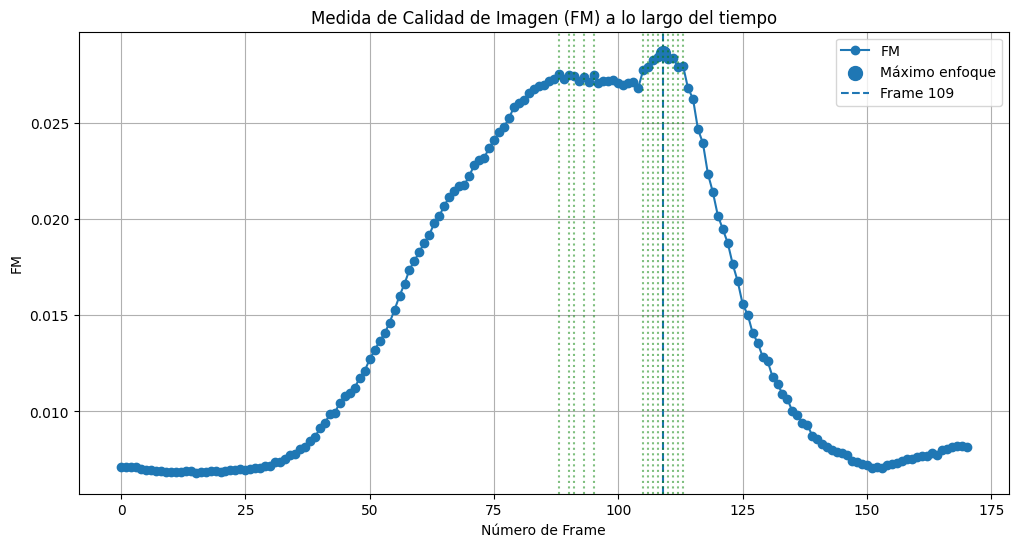

Frames enfocados (unsharp): [88, 90, 91, 93, 95, 105, 106, 107, 108, 109, 110, 111, 112, 113]
Umbral (FM) de enfoque (unsharp): 0.027300710903822155
Cantidad de frames enfocados: 14


In [41]:
# Verficar resultados originales
fm_values = IQM_fullFrame
frames_enfocados, umbral = detectar_frames_enfocados(fm_values, k=1.5)
graficar_curva_fm_con_enfoque(fm_values, frames_enfocados)
print(f"Frames enfocados (unsharp): {frames_enfocados}")
print(f"Umbral (FM) de enfoque (unsharp): {umbral}")
print(f"Cantidad de frames enfocados: {len(frames_enfocados)}")

Se procesaron 171 frames


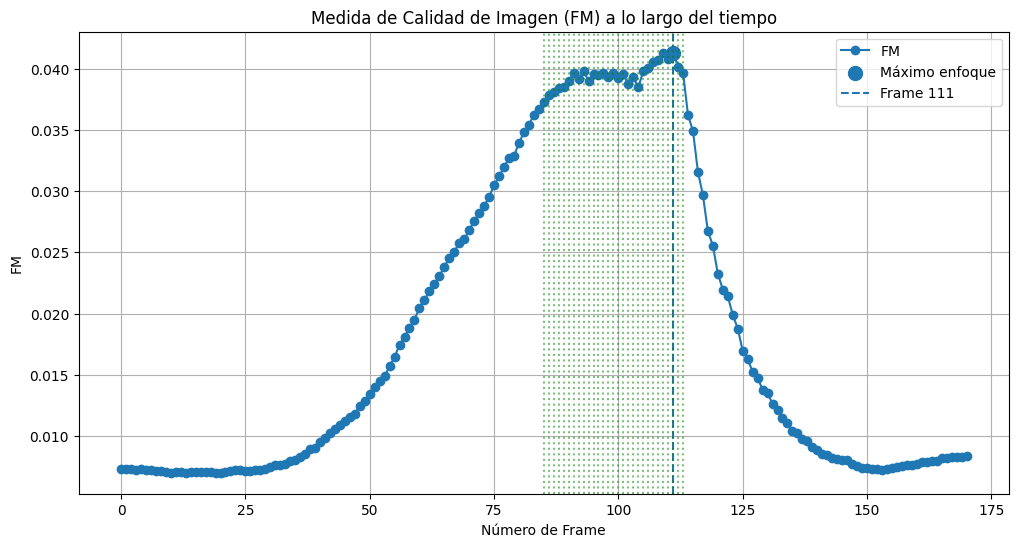

Frames enfocados (unsharp): [85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113]
Umbral (FM) de enfoque (unsharp): 0.037108406181671105
Cantidad de frames enfocados: 29


In [42]:
# Verificamos resultados con unsharp masking
fm_values_unsharp = calcular_fm_con_unsharp(video_path, roi=1)
frames_enfocados_unsharp, umbral_unsharp = detectar_frames_enfocados(fm_values_unsharp, k=1.5)
graficar_curva_fm_con_enfoque(fm_values_unsharp, frames_enfocados_unsharp)
print(f"Frames enfocados (unsharp): {frames_enfocados_unsharp}")
print(f"Umbral (FM) de enfoque (unsharp): {umbral_unsharp}")
print(f"Cantidad de frames enfocados: {len(frames_enfocados_unsharp)}")